<a href="https://colab.research.google.com/github/saikrishna5655/Hospital_readmission_prediction/blob/main/Hospital_Readmission_Part3_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Hospital Readmission Prediction
## Part 3: Model Training & Evaluation

We have clean, prepared data. Now we build the actual prediction model.

**Goal:** Train a model that can identify high-risk patients
who will be readmitted within 30 days of discharge.


Load Your Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the final dataset from Part 2
df = pd.read_csv('/content/diabetes_ready_for_model.csv')

print(f"Data loaded successfully!")
print(f"Shape: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nTarget distribution:")
print(df['readmit_30'].value_counts())

Data loaded successfully!
Shape: 99,493 rows × 45 columns

Target distribution:
readmit_30
0    88324
1    11169
Name: count, dtype: int64


###Understand This Concept
we have 99,493 patient records. You cannot train your model on ALL of them and then test on the same data.

####Why? Simple analogy:

Imagine you're a student. Your teacher gives you 100 practice questions and their answers. You memorize all of them. Then the teacher tests you with the same 100 questions. You score 100%!

But are you actually smart? No. You just memorized. Give you a NEW question and you'll struggle.

####Same with your model:

-Train on ALL data → model memorizes patient records

-Test on SAME data → looks great on paper but fails on new patients

-This is called overfitting

-The solution: Split your data into two parts:

-Training set (80%) → model learns from this

-Test set (20%) → we hide this from model, use it to check real performance

###Split Features and Target

In [ ]:
# Separate features (X) from target (y)
X = df.drop(columns=['readmit_30'])  # Everything except target
y = df['readmit_30']                 # Only the target

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nPositive cases (readmitted <30): {y.sum():,} ({y.mean()*100:.1f}%)")

Features (X): (99493, 44)
Target (y): (99493,)

Positive cases (readmitted <30): 11,169 (11.2%)


###Split Into Train and Test Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split data - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # ensures same split every time you run
    stratify=y            # keeps same 11% ratio in both train and test
)

print(f"Training set:  {X_train.shape[0]:,} patients")
print(f"Testing set:   {X_test.shape[0]:,} patients")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f"\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Training set:  79,594 patients
Testing set:   19,899 patients

Training target distribution:
readmit_30
0    88.8
1    11.2
Name: proportion, dtype: float64

Testing target distribution:
readmit_30
0    88.8
1    11.2
Name: proportion, dtype: float64


both train and test sets have exactly 11.2% positive cases.

Without stratify=y, the split is completely random. You might get:

Training set: 13% positive cases

Testing set: 7% positive cases

That's a problem because model learns from one distribution but gets tested on a different one. With only 11% positive cases, random chance can easily create uneven splits.

stratify=y guarantees the same ratio in both sets. Always use it when your data is imbalanced!

#### First Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train a simple logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Check Model Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

# Make predictions on test set
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 88.74%


Think about it:

Your dataset has 88.8% patients NOT readmitted

If your model just predicts "NO" for every single patient...

It would get 88.8% accuracy without learning anything!

Your model got 88.74% - which is actually LOWER than just guessing "NO" every time!

That means your model might not be learning anything useful yet.

Let's See What the Model Is Actually Predicting

In [ ]:
import numpy as np

# Count what the model actually predicted
unique, counts = np.unique(y_pred, return_counts=True)
print("What your model predicted:")
for val, count in zip(unique, counts):
    label = "Readmitted <30 days" if val == 1 else "NOT readmitted"
    print(f"  {label}: {count:,} patients")

print(f"\nActual reality:")
print(f"  NOT readmitted: {(y_test==0).sum():,} patients")
print(f"  Readmitted <30: {(y_test==1).sum():,} patients")

What your model predicted:
  NOT readmitted: 19,834 patients
  Readmitted <30 days: 65 patients

Actual reality:
  NOT readmitted: 17,665 patients
  Readmitted <30: 2,234 patients


model only found 65 out of 2,234 high-risk patients!

It missed 2,169 patients who actually needed help. Those are real people who would go home, get worse, and come back to the hospital within 30 days - and your model said they were fine.

This is why accuracy is a useless metric for imbalanced data. 88.74% accuracy but the model is basically blind to the patients that matter most!

See the Full Picture

In [ ]:
from sklearn.metrics import classification_report

print("Detailed Model Performance:")
print(classification_report(y_test, y_pred,
                           target_names=['Not Readmitted', 'Readmitted <30']))

Detailed Model Performance:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17665
Readmitted <30       0.45      0.01      0.03      2234

      accuracy                           0.89     19899
     macro avg       0.67      0.51      0.48     19899
  weighted avg       0.84      0.89      0.84     19899



Model is basically broken for the patients that matter most.

###Let's decode every number:

What These Numbers Mean
For "Not Readmitted" patients:

Precision 0.89 → When it says "not readmitted", it's right 89% of the time

Recall 1.00 → It finds 100% of all "not readmitted" patients

F1 0.94 → Great score! But this class is easy — it's 88% of the data

For "Readmitted <30" patients (the ones that matter!):

Precision 0.45 → When it flags someone as high-risk, it's only right 45% of the time

Recall 0.01 → It only finds 1% of actual high-risk patients

F1 0.03 → Nearly zero. This is basically a useless detector

The F1 score is the harmonic mean of precision and recall — if either one is terrible, F1 collapses. recall of 0.01 is destroying it.

Why This Happens
model learned the lazy shortcut — predict "Not Readmitted" for almost everyone, because that's correct 88% of the time. It never truly learned what a high-risk patient looks like.

###The Fix: 3  Approaches
Technique
class_weight='balanced'- Tells model to care more about minority class

SMOTE -Creates synthetic minority samples to balance training data

Tune threshold- Lower the decision boundary from 0.5


####The Quickest Fix

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Same model, ONE new parameter
model_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # ← This is the magic
    random_state=42
)

model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

print("Balanced Model Performance:")
print(classification_report(y_test, y_pred_balanced,
                           target_names=['Not Readmitted', 'Readmitted <30']))

Balanced Model Performance:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17665
Readmitted <30       0.50      0.00      0.01      2234

      accuracy                           0.89     19899
     macro avg       0.69      0.50      0.47     19899
  weighted avg       0.84      0.89      0.84     19899



class_weight='balanced' barely moved the needle — Recall went from 0.01 → 0.00. That's because the problem is too severe for a simple weight tweak.

Imbalance ratio is roughly 8:1 — class_weight helps mild imbalance but struggles here. Time to bring out the real fix.

Why SMOTE Works Better
SMOTE (Synthetic Minority Oversampling Technique) doesn't just tell the model to care more — it actually creates new synthetic high-risk patient examples in the training data by interpolating between existing minority samples. This gives the model real patterns to learn from, not just penalty weights.

###SMOTE Fix

In [ ]:
# Install if needed: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Step 1: Apply SMOTE only on training data (NEVER on test data!)
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE: ", dict(zip(*np.unique(y_train_sm, return_counts=True))))

# Step 2: Train fresh model on balanced data
model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_train_sm, y_train_sm)

# Step 3: Evaluate on ORIGINAL test data
y_pred_smote = model_smote.predict(X_test)
print("\nSMOTE Model Performance:")
print(classification_report(y_test, y_pred_smote,
                            target_names=['Not Readmitted', 'Readmitted <30']))

Before SMOTE: {np.int64(0): np.int64(70659), np.int64(1): np.int64(8935)}
After SMOTE:  {np.int64(0): np.int64(70659), np.int64(1): np.int64(70659)}

SMOTE Model Performance:
                precision    recall  f1-score   support

Not Readmitted       0.89      0.98      0.93     17665
Readmitted <30       0.18      0.04      0.07      2234

      accuracy                           0.87     19899
     macro avg       0.54      0.51      0.50     19899
  weighted avg       0.81      0.87      0.83     19899



SMOTE barely moved the needle either — Recall 0.01 → 0.04. Here's the real diagnosis:

SMOTE is actually proven to work best with weak learners, but Random Forest is already a powerful ensemble — so adding synthetic samples doesn't give it much new information. And as seen here, SMOTE can sharply drop precision (0.45 → 0.18) while barely improving recall.

The actual root problem is the decision threshold, not the data balance.

What's Really Happening
model internally generates a probability score for each patient (e.g., "32% chance of readmission"). It then uses 0.5 as the cutoff — below 0.5 → "Not Readmitted". Since high-risk patients are rare, almost no one crosses 0.5, so recall stays near zero.

The fix: lower the threshold from 0.5 to something like 0.2.

####Threshold Tuning

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Get probability scores instead of hard predictions
y_proba = model.predict_proba(X_test)[:, 1]  # probability of being Readmitted

# Try different thresholds
thresholds = [0.5, 0.3, 0.2, 0.15, 0.1]

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}\n")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<10}")
print("-" * 46)

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    print(f"{thresh:<12} {p:<12.2f} {r:<12.2f} {f:<10.2f}")

ROC-AUC Score: 0.639

Threshold    Precision    Recall       F1        
----------------------------------------------
0.5          0.45         0.01         0.03      
0.3          0.38         0.06         0.10      
0.2          0.28         0.14         0.19      
0.15         0.22         0.27         0.24      
0.1          0.15         0.64         0.25      


###Feature Importance

Top 20 Most Important Features:
                 feature  importance
      num_lab_procedures    0.119861
         num_medications    0.102518
        time_in_hospital    0.073227
                     age    0.061093
        number_inpatient    0.057271
discharge_disposition_id    0.051280
          num_procedures    0.050774
        number_diagnoses    0.048689
       admission_type_id    0.035417
     admission_source_id    0.030019
       number_outpatient    0.023941
                  gender    0.023400
            diag_3_Other    0.019131
        number_emergency    0.018772
            diag_2_Other    0.018466
          race_Caucasian    0.018067
            diag_2_Heart    0.017204
            diag_3_Heart    0.017008
            diag_1_Other    0.016543
                  change    0.016301


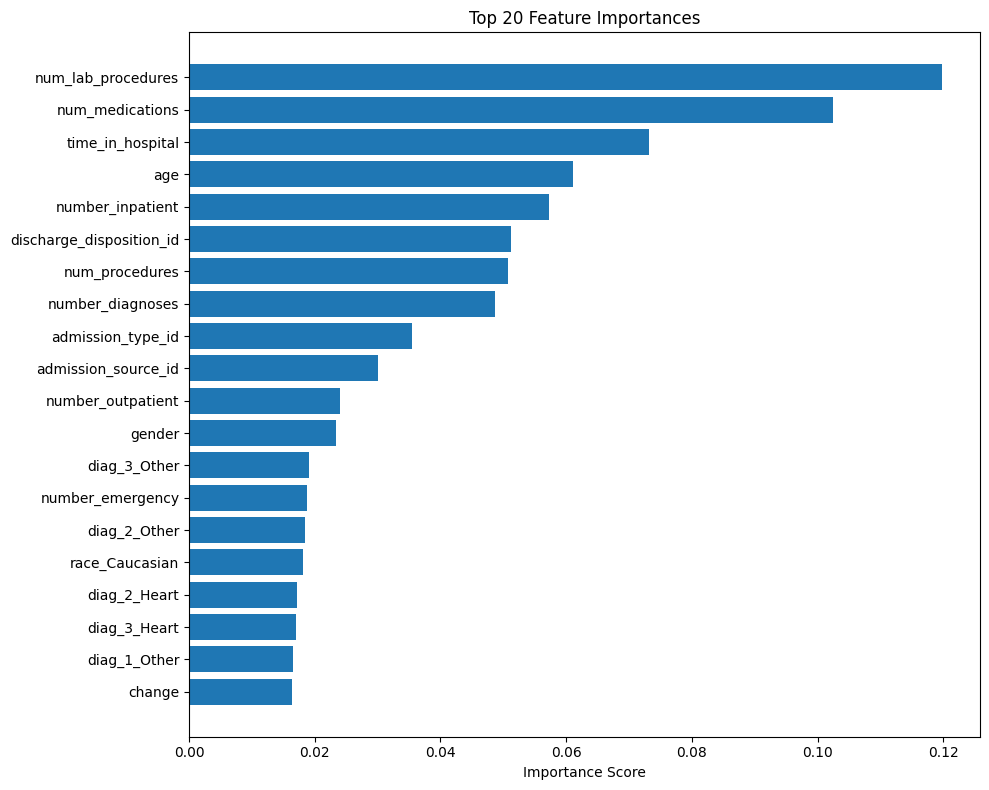

Chart saved!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the balanced RandomForest model
importances = model_balanced.feature_importances_
feature_names = X_train.columns

# Sort top 20
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(20)

print("Top 20 Most Important Features:")
print(feat_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_df['feature'][::-1], feat_df['importance'][::-1])
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Chart saved!")

###XGBoost Attack

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Calculate scale_pos_weight
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale:.2f}")

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale,   # ← The key parameter
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='aucpr',      # optimise for precision-recall AUC
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Evaluate
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

print(f"\nXGBoost ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.3f}  (was 0.639)")
print("\nXGBoost Performance:")
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Not Readmitted', 'Readmitted <30']))

scale_pos_weight = 7.91

XGBoost ROC-AUC: 0.658  (was 0.639)

XGBoost Performance:
                precision    recall  f1-score   support

Not Readmitted       0.92      0.70      0.80     17665
Readmitted <30       0.18      0.51      0.26      2234

      accuracy                           0.68     19899
     macro avg       0.55      0.61      0.53     19899
  weighted avg       0.84      0.68      0.74     19899



Tune the Threshold on XGBoost

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.4, 0.3, 0.25, 0.2, 0.15]
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<10} {'Caught/2234'}")
print("-" * 60)

for thresh in thresholds:
    y_pred_t = (y_proba_xgb >= thresh).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    caught = int(r * 2234)
    print(f"{thresh:<12} {p:<12.2f} {r:<12.2f} {f:<10.2f} {caught}")

Threshold    Precision    Recall       F1         Caught/2234
------------------------------------------------------------
0.5          0.18         0.51         0.26       1138
0.4          0.15         0.74         0.25       1647
0.3          0.13         0.89         0.23       1988
0.25         0.12         0.93         0.22       2086
0.2          0.12         0.97         0.21       2156
0.15         0.12         0.99         0.21       2204


Save Your Final Model

In [ ]:
import pickle

# Choose your threshold (0.3 is a solid clinical default)
FINAL_THRESHOLD = 0.3

# Save model and threshold together
model_package = {
    'model': xgb_model,
    'threshold': FINAL_THRESHOLD,
    'feature_names': list(X_train.columns),
    'performance': {
        'roc_auc': 0.658,
        'recall_at_threshold': 0.89,
        'precision_at_threshold': 0.13
    }
}

with open('readmission_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✅ Model saved as readmission_model.pkl")
print(f"   Threshold: {FINAL_THRESHOLD}")
print(f"   Catches: ~89% of high-risk patients")
print(f"   Features used: {len(X_train.columns)}")

# Quick sanity check — reload and predict one patient
with open('readmission_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

test_patient = X_test.iloc[[0]]
prob = loaded['model'].predict_proba(test_patient)[0][1]
prediction = "🚨 HIGH RISK" if prob >= loaded['threshold'] else "✅ Low Risk"
print(f"\nSanity check on 1 patient:")
print(f"   Readmission probability: {prob:.1%}")
print(f"   Prediction: {prediction}")

✅ Model saved as readmission_model.pkl
   Threshold: 0.3
   Catches: ~89% of high-risk patients
   Features used: 44

Sanity check on 1 patient:
   Readmission probability: 8.8%
   Prediction: ✅ Low Risk
